### Lista zadań 6 redukcja wymiarowości (PCA, SVD)

### Zadanie 2 - PCA - breast cancer Data set

Testowanie PCA

In [2]:
from sklearn.decomposition import PCA
import numpy as np
# Przykładowe dane wielowymiarowe
X = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
# Inicjalizacja obiektu PCA
pca = PCA(n_components=2)
# Dopasowanie PCA do danych i transformacja
X_pca = pca.fit_transform(X)
# Wyświetlenie nowych danych po zastosowaniu PCA
print("Nowe dane po zastosowaniu PCA:")
print(X_pca)


Nowe dane po zastosowaniu PCA:
[[-5.19615242e+00 -2.56395025e-16]
 [ 0.00000000e+00 -0.00000000e+00]
 [ 5.19615242e+00 -2.56395025e-16]]


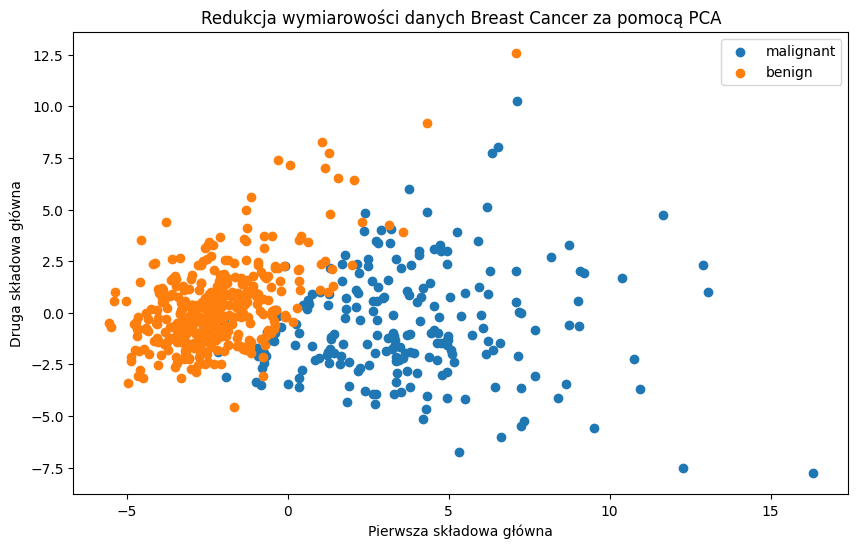

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



data = load_breast_cancer()

X = data.data  
y = data.target


# Standaryzacja 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Redukcja PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

# Wyświetlanie na wykresie
plt.figure(figsize=(10, 6))
for i in range(len(data.target_names)):
 plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=data.target_names[i])
 
plt.title('Redukcja wymiarowości danych Breast Cancer za pomocą PCA')
plt.xlabel('Pierwsza składowa główna')
plt.ylabel('Druga składowa główna')
plt.legend()
plt.show()



Zad 3 - t- SNE (PCA tylko że dla obrazków ), będziemy korzystać z digits dataset

Przykład testowy t -SNE

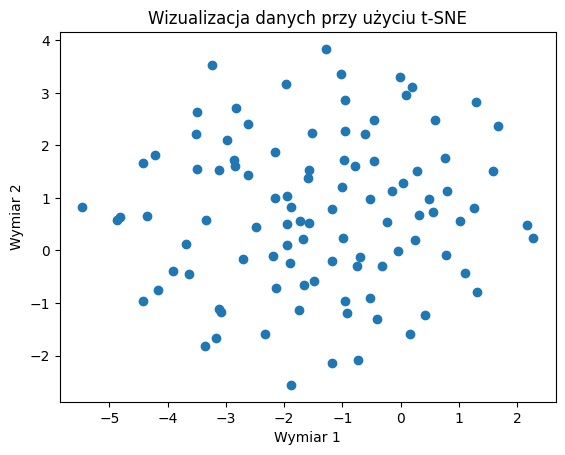

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# Generowanie losowych danych o wysokiej wymiarowości
X = np.random.randn(100, 50)
# Redukcja wymiarowości przy użyciu t-SNE
tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(X)
# Wizualizacja danych w nowej przestrzeni
plt.scatter(X_embedded[:, 0], X_embedded[:, 1])
plt.title('Wizualizacja danych przy użyciu t-SNE')
plt.xlabel('Wymiar 1')
plt.ylabel('Wymiar 2')
plt.show()

Przykład z digits dataset

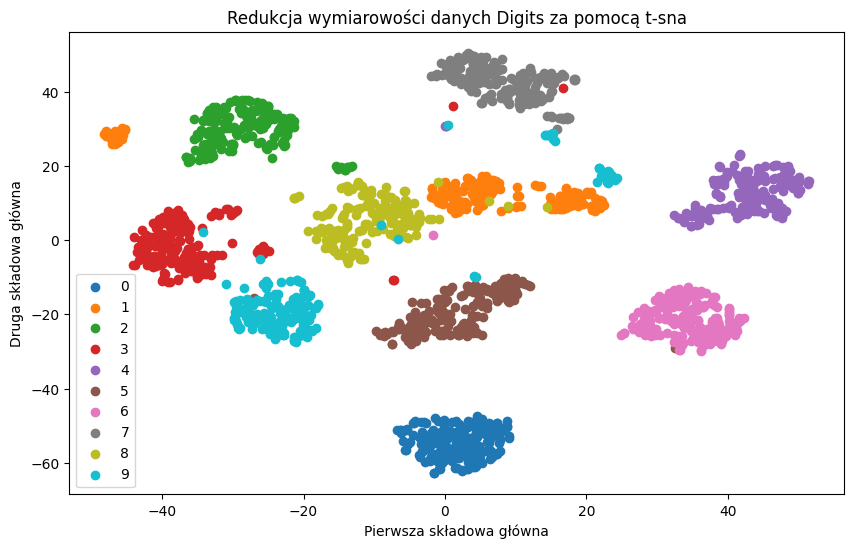

In [5]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

# Dane są już "spłaszczone" (macierz 1797 wierszy x 64 kolumny)
X = digits.data 
y = digits.target
"""
# Ale masz też dostęp do oryginalnych obrazów 8x8
images = digits.images 

print(f"Kształt danych: {X.shape}")      # (1797, 64)
print(f"Kształt obrazów: {images.shape}") # (1797, 8, 8)

plt.imshow(digits.images[0], cmap='gray_r')
plt.title(f"Etykieta: {digits.target[0]}")
plt.show()

"""

tsne = TSNE(n_components = 2)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
for i in range(len(digits.target_names)):
 plt.scatter(X_embedded[y == i, 0], X_embedded[y == i, 1], label=digits.target_names[i])
 
plt.title('Redukcja wymiarowości danych Digits za pomocą t-sna')
plt.xlabel('Pierwsza składowa główna')
plt.ylabel('Druga składowa główna')
plt.legend()
plt.show()



### Zad 4 Redukcja wymiarowości zbioru danych Labeled Faces - metoda NMF

Przykład testowy z NMF

c:\Users\maksp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


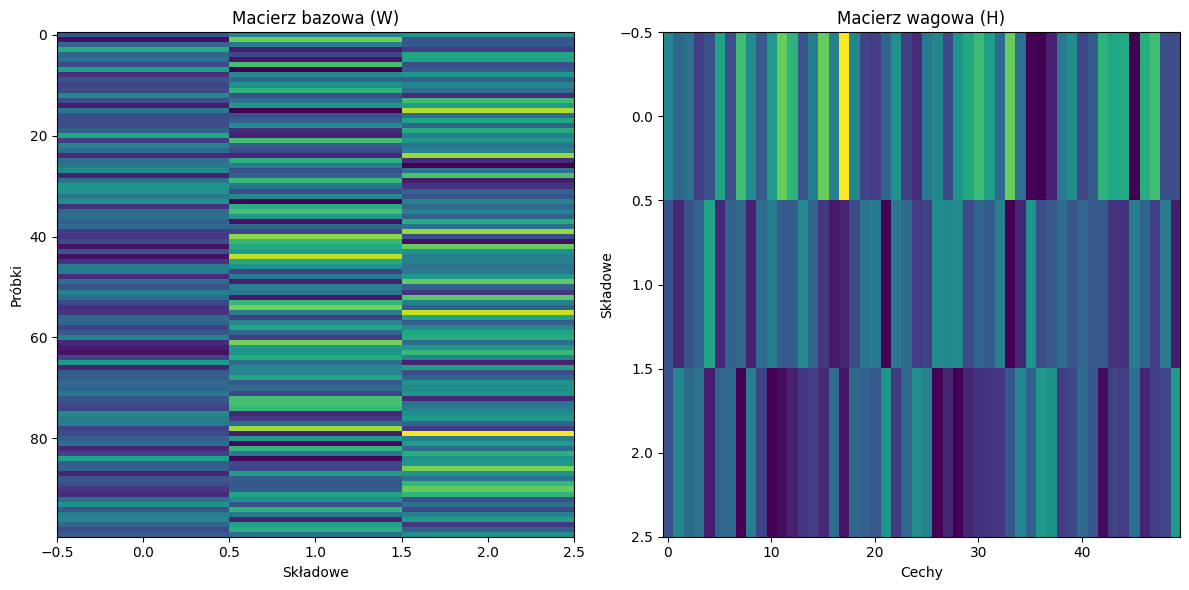

In [ ]:
import numpy as np
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

data = np.random.rand(100, 50) 

nmf_model = NMF(n_components=3) 

nmf_model.fit(data)

W = nmf_model.transform(data) 
H = nmf_model.components_ 

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(W, cmap='viridis', aspect='auto')
plt.title('Macierz bazowa (W)')
plt.xlabel('Składowe')
plt.ylabel('Próbki')
plt.subplot(1, 2, 2)
plt.imshow(H, cmap='viridis', aspect='auto')
plt.title('Macierz wagowa (H)')
plt.xlabel('Cechy')
plt.ylabel('Składowe')
plt.tight_layout()
plt.show()

NMF na zbioerz danych Labeled faces

c:\Users\maksp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


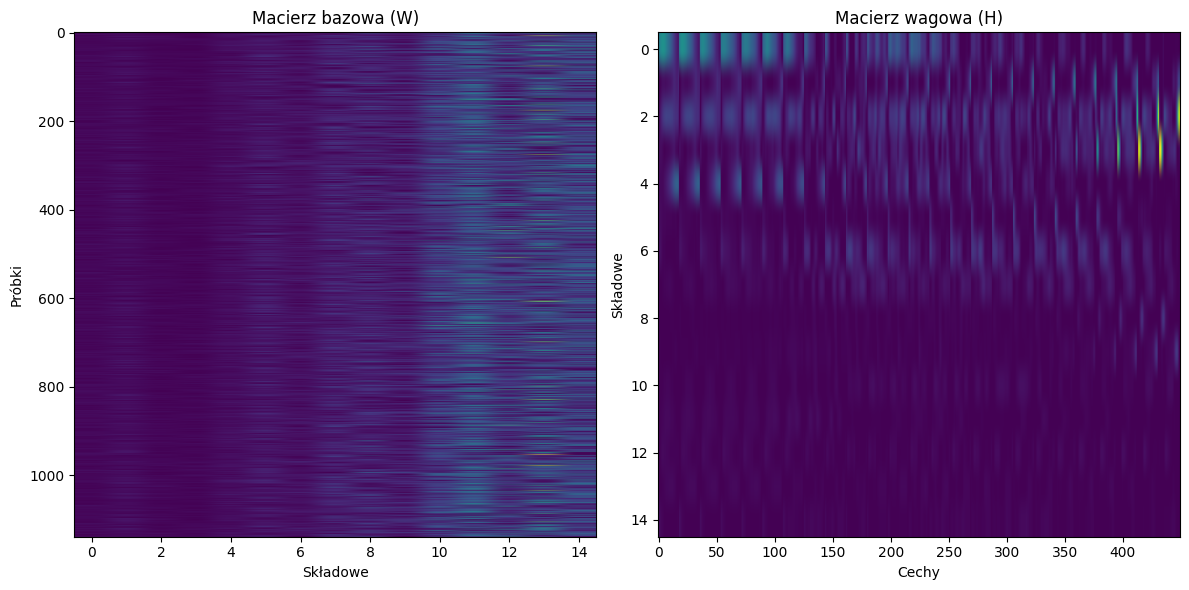

In [ ]:
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person = 100, resize = 0.2)

X = lfw_people.data
y = lfw_people.target

target_names = lfw_people.target_names

nmf_model = NMF(n_components = 15)
nmf_model.fit(X)

W = nmf_model.transform(X) 

H = nmf_model.components_


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(W, cmap='viridis', aspect='auto')
plt.title('Macierz bazowa (W)')
plt.xlabel('Składowe')
plt.ylabel('Próbki')
plt.subplot(1, 2, 2)
plt.imshow(H, cmap='viridis', aspect='auto')
plt.title('Macierz wagowa (H)')
plt.xlabel('Cechy')
plt.ylabel('Składowe')
plt.tight_layout()
plt.show()




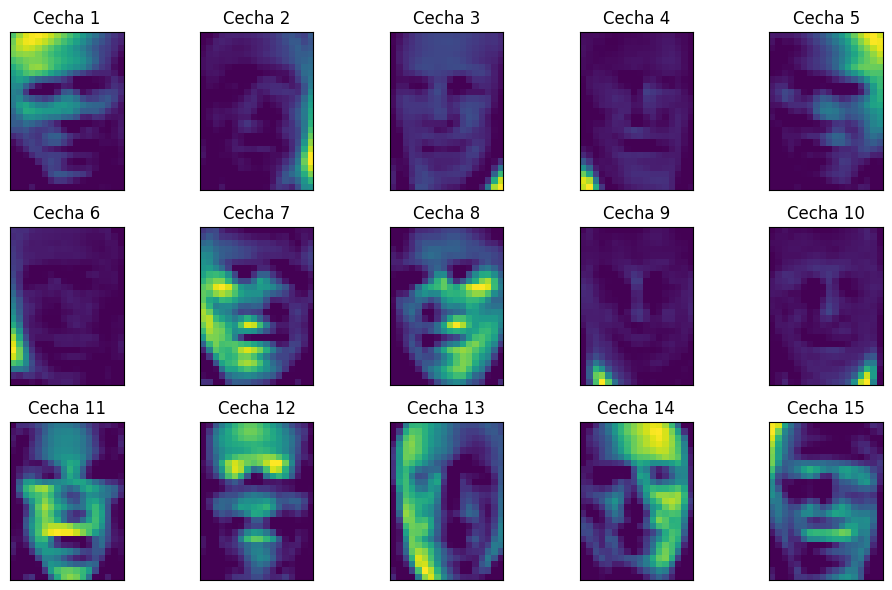

In [ ]:
import matplotlib.pyplot as plt


n_row, n_col = 3, 5 
n_samples, h, w = lfw_people.images.shape
plt.figure(figsize=(2 * n_col, 2 * n_row))


for i in range(n_row * n_col):
    plt.subplot(n_row, n_col, i + 1)
    
   
    feature_image = H[i].reshape((h, w))
    
    plt.imshow(feature_image, cmap='viridis') 
    plt.title(f"Cecha {i+1}")
    plt.xticks(()) 
    plt.yticks(())

plt.tight_layout()
plt.show()

### Zad 5 - SVD - wariancja przynajmniej 95 % + porównanie z orginalnym datasetem

### Przykładowy kod do SVD

In [ ]:
import numpy as np

data = np.array([[1, 2, 3],
 [4, 5, 6],
[7, 8, 9],
[10, 11, 12],
[13, 14, 15]])

U, s, VT = np.linalg.svd(data)

k = 2

reduced_data = np.dot(U[:, :k], np.diag(s[:k]))
print("Zredukowane dane:")
print(reduced_data)


Zredukowane dane:
[[ -3.56562055   1.13417375]
 [ -8.74530703   0.72083623]
 [-13.92499352   0.30749871]
 [-19.10468001  -0.10583881]
 [-24.28436649  -0.51917633]]


### Dane - Wino

cumulative variance: [0.99790749 0.99995858 0.99998608 0.99999371 0.9999966  0.99999836
 0.99999939 0.99999962 0.99999979 0.9999999  0.99999995 0.99999999
 1.        ]
k : 2
Zredukowane dane:
 [[-1.07275836e+03 -9.67324841e-01]
 [-1.05462161e+03  2.43108121e+01]
 [-1.18895307e+03  3.75913121e+01]
 [-1.48324411e+03  6.12935580e+01]
 [-7.44147210e+02 -3.25753080e+01]
 [-1.45329348e+03  5.91413091e+01]
 [-1.29255679e+03  5.56541867e+01]
 [-1.30046887e+03  3.16564434e+01]
 [-1.04939991e+03  2.57395543e+01]
 [-1.04955825e+03  2.43575636e+01]
 [-1.51211318e+03  7.23554692e+01]
 [-1.28254819e+03  5.50007323e+01]
 [-1.32155586e+03  6.56751794e+01]
 [-1.15291192e+03  4.45113018e+01]
 [-1.54839264e+03  8.08913532e+01]
 [-1.31432065e+03  4.21303033e+01]
 [-1.28552183e+03  3.02261696e+01]
 [-1.13600125e+03  1.72727461e+01]
 [-1.68124228e+03  8.98946239e+01]
 [-8.53025373e+02 -1.63727677e+01]
 [-7.89667103e+02 -3.38826047e+01]
 [-7.76997903e+02 -1.25547286e+01]
 [-1.03996670e+03  2.02779160e+01]
 [

C:\Users\maksp\AppData\Local\Temp\ipykernel_13492\2145853357.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


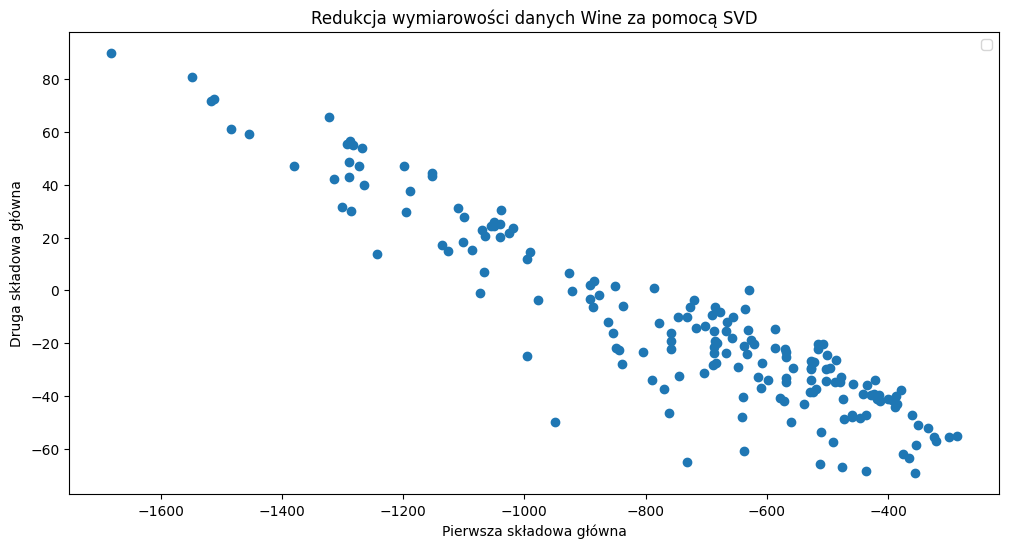

In [ ]:
from sklearn.datasets import load_wine
import numpy as np

wine = load_wine()


X = wine.data
y = wine.target

U, s, VT = np.linalg.svd(X)

calculate_varience = s**2/ (np.sum(s**2))
cumulative_variance = np.cumsum(calculate_varience)

print(f'cumulative variance: {cumulative_variance}')
k = np.argmax(cumulative_variance >= 0.998) + 1
print(f'k : {k}')

reduced_data = np.dot(U[:, :k], np.diag(s[:k]))
print("Zredukowane dane:\n", reduced_data)


plt.figure(figsize=(12, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1] )
#plt.scatter(X[:, 0], X[:, 1] )



plt.title('Redukcja wymiarowości danych Wine za pomocą SVD')
plt.xlabel('Pierwsza składowa główna')
plt.ylabel('Druga składowa główna')
plt.legend()
plt.show()



### Zad 6 20 Newsgroups dataset

### Przykład zastosowania LDA

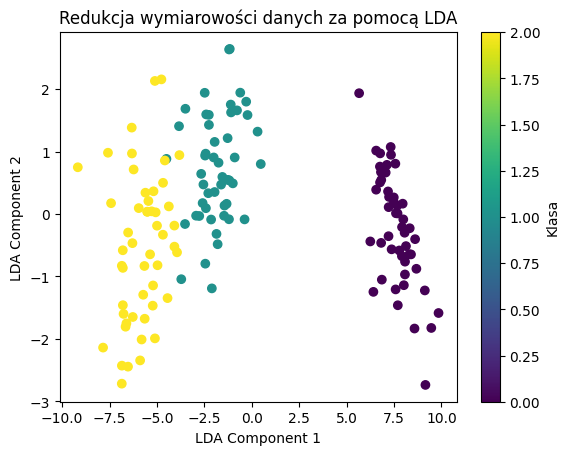

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('Redukcja wymiarowości danych za pomocą LDA')
plt.colorbar(label='Klasa')
plt.show()


In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

newsgroups = fetch_20newsgroups(subset = 'test', remove = ('headers', 'footers', 'quotes'))



print(f"Liczba wczytanych dokumentów: {len(newsgroups.data)}")
print(f"Wczytane kategorie: {newsgroups.target_names}\n")

vectorizer = CountVectorizer(stop_words = 'english', lowercase = True, max_features = 2000)

cleaned_dataset = vectorizer.fit_transform(newsgroups.data)

vectorizer.get_feature_names_out()

print(f"Kształt macierzy: {cleaned_dataset.shape}")


feature_names = vectorizer.get_feature_names_out()
print(f"Przykładowe wyciągnięte słowa: {feature_names[100:120]}")


Liczba wczytanych dokumentów: 7532
Wczytane kategorie: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Kształt macierzy: (7532, 2000)
Przykładowe wyciągnięte słowa: ['84' '85' '88' '89' '90' '91' '92' '93' '95' '99' '__' '_____' 'ability'
 'able' 'absolutely' 'abuse' 'ac' 'accept' 'accepted' 'access']


(7532, 2)


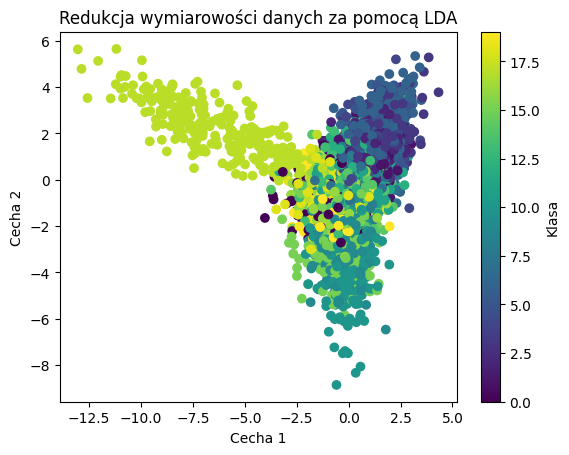

In [48]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

y = newsgroups.target

lda = LDA(n_components = 2)
X_lda = lda.fit_transform(cleaned_dataset.toarray(),y)

print(X_lda.shape)

# tworzenie wykresow
plt.scatter(X_lda[:, 0], X_lda[:, 1], c = y, cmap = 'viridis' )
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.title('Redukcja wymiarowości danych za pomocą LDA')
plt.colorbar(label='Klasa')
plt.show()

### Analiza cech w zbiorze

In [ ]:
import numpy as np


feature_names = vectorizer.get_feature_names_out()

# 2. Pobieramy nazwy kategorii
target_names = newsgroups.target_names

print("--- ANALIZA WAŻNOŚCI SŁÓW DLA POSZCZEGÓLNYCH KATEGORII ---\n")

# 3. Przechodzimy w pętli przez każdą kategorię
for i, category_name in enumerate(target_names):
    
  
    top_word_indices = np.argsort(lda.coef_[i])[-10:]
    
    
    top_words = [feature_names[index] for index in top_word_indices]
    
    
    top_words.reverse()
    
    print(f"Kategoria: {category_name}")
    print(f"Główne słowa (tematyka): {', '.join(top_words)}\n")

--- ANALIZA WAŻNOŚCI SŁÓW DLA POSZCZEGÓLNYCH KATEGORII ---

Kategoria: alt.atheism
Główne słowa (tematyka): bullock, contain, atheists, bank, appearance, discuss, quoted, context, islam, verses

Kategoria: comp.graphics
Główne słowa (tematyka): viewer, map, 3d, newsletter, mil, astronomy, graphics, convert, 64, lcs

Kategoria: comp.os.ms-windows.misc
Główne słowa (tematyka): mcconkie, microsoft, 61, font, 46, editor, windows, elohim, shareware, bullock

Kategoria: comp.sys.ibm.pc.hardware
Główne słowa (tematyka): ip, tor, 286, bios, addresses, 66, motherboard, readme, bullock, 2000

Kategoria: comp.sys.mac.hardware
Główne słowa (tematyka): lc, tech, 72, prices, mac, computers, apple, fail, upgrade, se

Kategoria: comp.windows.x
Główne słowa (tematyka): mcconkie, contrib, motif, x11r5, servers, libraries, bullock, displays, welcome, patch

Kategoria: misc.forsale
Główne słowa (tematyka): sale, shipping, offer, condition, bullock, excellent, moving, includes, selling, 85

Kategoria: rec.

### Zad 6 porównanie metod redukcji wymiarowości: PCA, NMF, t - SNE

In [34]:
import pandas as pd
df = pd.read_csv('./Data/MentalHealthDataset.csv')
df.head()


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [42]:

kolumny_do_usuniecia = [ 'Country', 'Occupation', 'treatment', 'care_options', 
                        'mental_health_interview', 'self_employed', 'Timestamp']


labels = df['treatment']
df_cleaned = df.drop( columns = kolumny_do_usuniecia )



df_cleaned.head()
#print(labels)

,Gender,family_history,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness
0,Female,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes
1,Female,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes
2,Female,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes
3,Female,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes
4,Female,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes


In [43]:
#df_cleaned['self_employed'] = df_cleaned['self_employed'].fillna('No')
for kolumna in df_cleaned.columns:
    unikalne_wartosci = df_cleaned[kolumna].unique()
    print(f"{kolumna}: {unikalne_wartosci}")



Gender: ['Female' 'Male']
family_history: ['No' 'Yes']
Days_Indoors: ['1-14 days' 'Go out Every day' 'More than 2 months' '15-30 days'
 '31-60 days']
Growing_Stress: ['Yes' 'No' 'Maybe']
Changes_Habits: ['No' 'Yes' 'Maybe']
Mental_Health_History: ['Yes' 'No' 'Maybe']
Mood_Swings: ['Medium' 'Low' 'High']
Coping_Struggles: ['No' 'Yes']
Work_Interest: ['No' 'Maybe' 'Yes']
Social_Weakness: ['Yes' 'No' 'Maybe']


In [44]:

gender_map = {'Female': 0, 'Male' : 1} # gender
binary_map = {'No' : 0, 'Yes' : 1} # self_employed, family_history, Coping_Struggles
days_map = {
    'Go out Every day': 0,
    '1-14 days': 1,
    '15-30 days': 2,
    '31-60 days': 3,
    'More than 2 months': 4
}

extended_binary = {'Yes': 2, 'Maybe' : 1, 'No' : 0} # Growing_stress, changes_Habits, 
#Mental_Health_History, Scial_Weakness

reverse_extended_binary = {'Yes': 0, 'Maybe' : 1, 'No' : 2} #Work_Interest
level = {'Low' : 0, 'Medium' : 1, 'High' : 2 } # Mood_Swings

df_cleaned['Gender'] = df_cleaned['Gender'].map(gender_map)
#df_cleaned['self_employed'] = df_cleaned['self_employed'].map(binary_map)
df_cleaned['family_history'] = df_cleaned['family_history'].map(binary_map)
df_cleaned['Days_Indoors'] = df_cleaned['Days_Indoors'].map(days_map)
df_cleaned['Growing_Stress'] = df_cleaned['Growing_Stress'].map(extended_binary)
df_cleaned['Changes_Habits'] = df_cleaned['Changes_Habits'].map(extended_binary)
df_cleaned['Mental_Health_History'] = df_cleaned['Mental_Health_History'].map(extended_binary)
df_cleaned['Mood_Swings'] = df_cleaned['Mood_Swings'].map(level)
df_cleaned['Coping_Struggles'] = df_cleaned['Coping_Struggles'].map(binary_map)
df_cleaned['Work_Interest'] = df_cleaned['Work_Interest'].map(reverse_extended_binary)
df_cleaned['Social_Weakness'] = df_cleaned['Social_Weakness'].map(extended_binary)
labels = labels.map(binary_map)
df_cleaned.head()


,Gender,family_history,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness
0,0,0,1,2,0,2,1,0,2,2
1,0,1,1,2,0,2,1,0,2,2
2,0,1,1,2,0,2,1,0,2,2
3,0,1,1,2,0,2,1,0,2,2
4,0,1,1,2,0,2,1,0,2,2


In [46]:
print(df_cleaned.shape)
print(df_cleaned.dtypes)

(292364, 10)
Gender                   int64
family_history           int64
Days_Indoors             int64
Growing_Stress           int64
Changes_Habits           int64
Mental_Health_History    int64
Mood_Swings              int64
Coping_Struggles         int64
Work_Interest            int64
Social_Weakness          int64
dtype: object


Suma wartości w kolumnach (czy nie są zerowe?):
Gender                   4069
family_history           2046
Days_Indoors             9966
Growing_Stress           5125
Changes_Habits           5387
Mental_Health_History    4769
Mood_Swings              4824
Coping_Struggles         2396
Work_Interest            5289
Social_Weakness          4940
dtype: int64


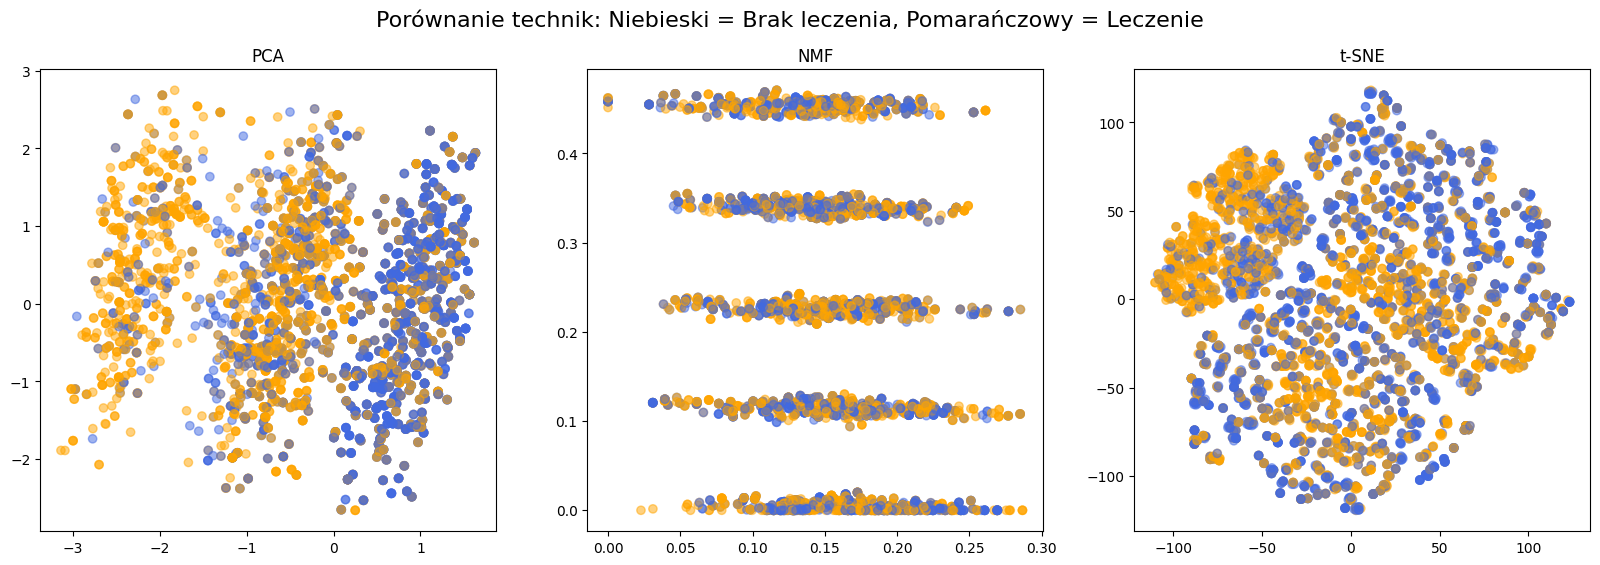

In [ ]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

df_sampled = df_cleaned.sample(n=5000, random_state=42)
labels_sampled = labels.loc[df_sampled.index]


print("Suma wartości w kolumnach (czy nie są zerowe?):")
print(df_sampled.sum())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sampled)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


nmf_model = NMF(n_components=2, max_iter=1000)
W = nmf_model.fit_transform(df_sampled)


tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)




labels_sampled = labels.loc[df_sampled.index].astype(int)


color_map = {0: 'royalblue', 1: 'orange'}
colors_final = labels_sampled.map(color_map).fillna('black') 


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_final, alpha=0.5)
axes[0].set_title('PCA')

axes[1].scatter(W[:, 0], W[:, 1], c=colors_final, alpha=0.5)
axes[1].set_title('NMF')

axes[2].scatter(X_embedded[:, 0], X_embedded[:, 1], c=colors_final, alpha=0.5)
axes[2].set_title('t-SNE')

plt.suptitle('Porównanie technik: Niebieski = Brak leczenia, Pomarańczowy = Leczenie', fontsize=16)
plt.show()
